# [Step 6 - MarkdownHeaderTextSplitter] Structure-aware splitting

**MLCourse - Agentic AI - Module 06: Chunking Strategies**

> Stage in the capstone: stage 2 CHUNK: chunk quality decides retrieval accuracy in the capstone.

## What you'll learn

- splitting BY document structure (`#`/`##`/`###`) instead of by character count
- header LINEAGE landing in metadata - the killer feature for citations
- why a retrieved chunk knowing its OWN section changes answer quality
- the standard combo: header split first, then a size splitter per section

---

In [1]:
# =====================================================================
# CELL 1 - SHARED SETUP: imports, track discovery, download-once cache
# =====================================================================

# --- Standard library -------------------------------------------------
import os                      # file-system odds and ends
import urllib.request          # kept for parity with sibling notebooks
from pathlib import Path       # object-oriented filesystem paths

# --- Lesson-specific imports ------------------------------------------
import matplotlib.pyplot as plt                                  # histograms
from langchain_text_splitters import (
    MarkdownHeaderTextSplitter,        # today's hero: splits on ATX headers
    RecursiveCharacterTextSplitter,    # tomorrow's teammate: enforces sizes
)

# ---------------------------------------------------------------------
# TRACK WALKER - resolve 03_agentic_ai by walking upward from cwd.
# ---------------------------------------------------------------------
def _find_track(start: Path) -> Path:
    """Return the absolute path of the 03_agentic_ai track root."""
    for candidate in (start, *start.parents):
        hit = candidate / "03_agentic_ai"
        if hit.is_dir():
            return hit.resolve()
    raise FileNotFoundError(
        f"No directory named 03_agentic_ai found above {start} - "
        "run this notebook from somewhere inside the MLCourse repo."
    )

TRACK = _find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# DOWNLOAD-ONCE HELPERS - present for consistency; today's specimen is the
# module's OWN README, no internet required.
# ---------------------------------------------------------------------
def get_bytes(fname: str, url: str) -> bytes:
    """Return the file's bytes, downloading only on the very first call."""
    target = DATA / fname
    if target.exists() and target.stat().st_size > 0:
        payload = target.read_bytes()
        print(f"[cache] {fname}: {len(payload):,} bytes")
        return payload
    print(f"[fetch] {url}")
    request = urllib.request.Request(url, headers={"User-Agent": "MLCourse/1.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        payload = response.read()
    target.write_bytes(payload)
    print(f"[saved] {fname}: {len(payload):,} bytes")
    return payload

def to_ascii(text: str) -> str:
    """Console-safe printing for arbitrary text."""
    return text.encode("ascii", errors="replace").decode("ascii")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# =====================================================================
# ANALYSIS TOOLBOX - identical across chunking notebooks.
# =====================================================================
SENTENCE_ENDS = tuple(".!?\"')")

def ends_naturally(chunk: str) -> bool:
    """Heuristic: a CLEAN chunk tail ends in sentence-final punctuation."""
    tail = chunk.rstrip()
    return (not tail) or tail.endswith(SENTENCE_ENDS)

def cut_report(chunks):
    """Return (offending chunks, percent cut mid-sentence)."""
    bad = [c for c in chunks if not ends_naturally(c)]
    pct = 100.0 * len(bad) / max(len(chunks), 1)
    return bad, pct

def plot_hist(sizes_list, title):
    plt.figure(figsize=(8, 3))
    plt.hist(sizes_list, bins=25, color="#4c72b0", edgecolor="white")
    plt.title(title)
    plt.xlabel("section size (characters)")
    plt.ylabel("number of sections")
    plt.tight_layout()
    plt.show()

## 1. WHAT it does, WHY it is different

Everything so far counted characters. But markdown documents DECLARE their
structure: `#` H1, `##` H2, `###` H3. `MarkdownHeaderTextSplitter`
reads those declarations and emits ONE DOCUMENT PER SECTION:

- content = everything under a header until the NEXT header of same/higher rank;
- metadata = the header LINEAGE, e.g. `{"H1": "...", "H2": "..."}`;
- no chunk_size anywhere - sections may be tiny or enormous.

### The killer feature: a chunk that knows its own address

When retrieval returns a chunk whose metadata says
`H1='Step 6 - Chunking...' , H2='Overlap theory'`, three things improve:

1. **Answers cite precisely** ('per the Overlap theory section...');
2. **Filters become possible** (search ONLY the decision guide);
3. **Chunks carry built-in context** - the header names explain the body,
  no surrounding text needed.

Specimen: this track's own `06_chunking_strategies/README.md`. Real
markdown, written for humans, ingested like production docs would be.

In [2]:
readme_path = TRACK / "06_chunking_strategies" / "README.md"
if not readme_path.exists():
    raise FileNotFoundError(
        f"Expected the chunking README at:\n  {readme_path}\n"
        "Keep the 06_chunking_strategies folder beside 05_document_loaders."
    )
md_text = readme_path.read_text(encoding="utf-8")
print(f"loaded course README : {len(md_text):,} chars")

header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[
        ("#", "H1"),      # metadata key for level-1 headers
        ("##", "H2"),     # metadata key for level-2 headers
        ("###", "H3"),    # metadata key for level-3 headers
    ],
    strip_headers=True,   # default: header lines leave the content...
                          # ...because they now LIVE in metadata
)
section_docs = header_splitter.split_text(md_text)

print(f"sections produced    : {len(section_docs)}")
print("\n--- first 3 sections: lineage + opening line ---")
for d in section_docs[:3]:
    first_line = d.page_content.strip().splitlines()[0][:70]
    print(f"{d.metadata}")
    print(f"   opens with: {to_ascii(first_line)}\n")

loaded course README : 7,451 chars
sections produced    : 10

--- first 3 sections: lineage + opening line ---
{'H1': '[Step 6 - Chunking Strategies] Cutting text so retrieval can win'}
   opens with: > **MLCourse - Agentic AI - Module 06: Chunking Strategies**  

{'H1': '[Step 6 - Chunking Strategies] Cutting text so retrieval can win', 'H2': "What you'll learn"}
   opens with: - why the chunk boundary - not the model - often decides RAG accuracy

{'H1': '[Step 6 - Chunking Strategies] Cutting text so retrieval can win', 'H2': '1. Why chunking decides RAG quality'}
   opens with: Retrieval never sees your documents. It sees CHUNKS - the fragments yo



## 3. The killer feature, demonstrated

Ask one section WHERE it lives. Character splitters cannot answer; here
the chunk itself carries the address.

In [3]:
target = next(
    (d for d in section_docs if d.metadata.get("H2") == "Overlap theory"),
    section_docs[1],
)
print("SECTION ADDRESS (metadata):", target.metadata)
print("\nfirst 240 chars of ITS content:")
print(to_ascii(target.page_content[:240]))

# Imagine a chatbot citing this: 'According to the Overlap theory section
# of the chunking README ... stride equals chunk size minus overlap.'
# That citation came FREE with the split.

SECTION ADDRESS (metadata): {'H1': '[Step 6 - Chunking Strategies] Cutting text so retrieval can win', 'H2': "What you'll learn"}

first 240 chars of ITS content:
- why the chunk boundary - not the model - often decides RAG accuracy
- how overlap works, why it exists, and what it costs when overused
- how to reason about chunk SIZE as a precision-versus-completeness dial
- which splitter fits which d


## 4. The `strip_headers` toggle

Default behaviour moves headers OUT of content (they live in metadata).
Flip to `strip_headers=False` and each section RE-STARTS with its header
line - useful when downstream consumers read raw text without metadata.

In [4]:
keep_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[("#", "H1"), ("##", "H2"), ("###", "H3")],
    strip_headers=False,
)
kept_docs = keep_splitter.split_text(md_text)

print(f"sections either way  : stripped={len(section_docs)}, kept={len(kept_docs)}")
print("\nsame section, header KEPT in content:")
print(to_ascii(kept_docs[0].page_content[:120]))

sections either way  : stripped=10, kept=10

same section, header KEPT in content:
# [Step 6 - Chunking Strategies] Cutting text so retrieval can win  
> **MLCourse - Agentic AI - Module 06: Chunking Str


## 5. The standard combo: structure first, size second

Sections vary wildly in length - and huge sections still blur embeddings.
Production pattern: header split for LINEAGE, then a recursive size pass
PER SECTION. `create_documents(..., metadatas=...)` copies each section's
lineage onto every sub-chunk, so addresses survive downsizing.

sections -> final chunks : 10 -> 26
largest section 1194 chars -> largest chunk 397 chars (cap enforced)


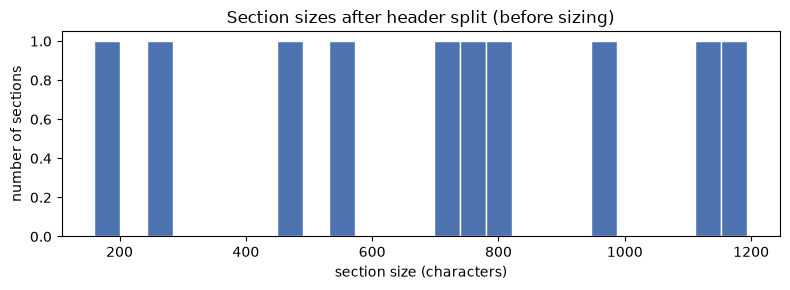

mid-sentence cuts: sections-only=40.0%  after size pass=61.5%

a random FINAL chunk keeps its full address:
{'H1': '[Step 6 - Chunking Strategies] Cutting text so retrieval can win', 'H2': '4. Strategy comparison matrix'}
| TokenTextSplitter | tokenizer boundaries (`cl100k_base` etc.) | no - pure budget control | LLM context budgets, billing-sensitive apps | i


In [5]:
size_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=60)
final_docs = size_splitter.create_documents(
    [d.page_content for d in section_docs],      # texts
    metadatas=[d.metadata for d in section_docs],   # lineage copied through!
)

sec_sizes = [len(d.page_content) for d in section_docs]
fin_sizes = [len(d.page_content) for d in final_docs]

print(f"sections -> final chunks : {len(section_docs)} -> {len(final_docs)}")
print(f"largest section {max(sec_sizes)} chars -> largest chunk "
      f"{max(fin_sizes)} chars (cap enforced)")

plot_hist(sec_sizes, "Section sizes after header split (before sizing)")
_, pct_sections = cut_report([d.page_content for d in section_docs])
_, pct_final = cut_report([d.page_content for d in final_docs])
print(f"mid-sentence cuts: sections-only={pct_sections:.1f}%  "
      f"after size pass={pct_final:.1f}%")

sample = final_docs[len(final_docs) // 2]
print("\na random FINAL chunk keeps its full address:")
print(sample.metadata)
print(to_ascii(sample.page_content[:140]))

## 6. Pitfalls worth remembering

**Pitfall - no size control alone**: one sprawling H2 becomes one giant
chunk. Always follow with a size splitter when embedding budgets matter -
the combo above IS the production recipe.

**Pitfall - non-markdown gets nothing**: feed plain prose and there are no
`#` lines to find - you receive one giant Document (notebook 06 shows this
failure on Alice verbatim). Route markdown to THIS splitter, prose to
recursive.

**Pro-tip**: extend `headers_to_split_on` with `("####", "H4")` for deep
docs - but remember deeper lineage means narrower, smaller sections.

## Takeaway

**Structure-aware splitting replaces counting with reading: sections stay
semantically whole, and every chunk ships with its own bibliographic
address. Header split for meaning, size split for budgets - in that order.**

## Summary

- The course README became one Document per section, with H1/H2/H3 lineage
  in metadata and zero character-count guesswork.
- The 'where am I?' demo showed metadata answering instantly - the property
  that powers precise citations and scoped filters.
- `strip_headers=False` keeps header lines inline for raw-text consumers;
  the default feeds them to metadata instead.
- The two-stage pipeline (header -> recursive 400/60) enforced size caps
  while PRESERVING lineage on every final chunk.